**Build real dataset**

In [1]:
from scripts.build_dataset import build_dataset

DATASET_BUILDS = [
    ("all", None),

    ("train_no_holdout", "CBr"),
    ("test_only_holdout", "CBr"),

    ("train_no_holdout", "carbonyl_O"),
    ("test_only_holdout", "carbonyl_O"),

    ("train_no_holdout", "aromatic_C"),
    ("test_only_holdout", "aromatic_C"),
]

for split_mode, holdout_name in DATASET_BUILDS:

    build_dataset(
        rep="matscholar",
        split_mode=split_mode,
        holdout_name=holdout_name,
    )

REP = matscholar
SPLIT_MODE = all
HOLDOUT = None
Loaded env vectors: 1052
Feature dim: 1012
Dataset build complete.
REP = matscholar
SPLIT_MODE = train_no_holdout
HOLDOUT = CBr
Loaded env vectors: 1052
Feature dim: 1012
Dataset build complete.
REP = matscholar
SPLIT_MODE = test_only_holdout
HOLDOUT = CBr
Loaded env vectors: 1052
Feature dim: 1012
Dataset build complete.
REP = matscholar
SPLIT_MODE = train_no_holdout
HOLDOUT = carbonyl_O
Loaded env vectors: 1052
Feature dim: 1012
Dataset build complete.
REP = matscholar
SPLIT_MODE = test_only_holdout
HOLDOUT = carbonyl_O
Loaded env vectors: 1052
Feature dim: 1012
Dataset build complete.
REP = matscholar
SPLIT_MODE = train_no_holdout
HOLDOUT = aromatic_C
Loaded env vectors: 1052
Feature dim: 1012
Dataset build complete.
REP = matscholar
SPLIT_MODE = test_only_holdout
HOLDOUT = aromatic_C
Loaded env vectors: 1052
Feature dim: 1012
Dataset build complete.


Visualise example spectra from the dataset

Number of real spectra found: 200
Selected spectra:
- Ethylcellulose (ECEL)
- poly(trifluoroethyl acrylate) (PTFEA)
- poly(4-bromostyrene) (PBS)


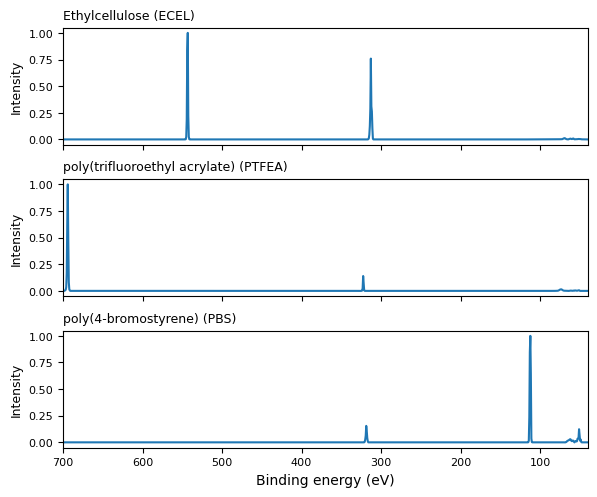

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# =========================
# LOAD DATASET
# =========================
ds = torch.load("dataset_soap.pt")

# =========================
# COLLECT REAL SPECTRA ONLY
# =========================
real_items = []
for item in ds:
    if item.get("is_synthetic", False):
        continue
    real_items.append(item)

print("Number of real spectra found:", len(real_items))

# =========================
# HELPER FUNCTIONS
# =========================
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.cpu().numpy()
    return np.asarray(x)

def get_name(item):
    name = item.get("key") or item.get("name") or "unknown"
    name = str(name)

    # shorten very long titles for plotting
    replacements = {
        "N,N'-Diphenyl-1,4-phenylenediamine [poly(aniline) oligomer]": "Poly(aniline) oligomer",
        "Hydroxypropylcellulose": "Hydroxypropylcellulose (HPCEL)",
        "Ethylcellulose": "Ethylcellulose (ECEL)",
    }
    return replacements.get(name, name)

def normalise(y):
    y = y.astype(float)
    y = y - y.min()
    if y.max() > 0:
        y = y / y.max()
    return y

def cosine_distance(a, b):
    denom = (np.linalg.norm(a) * np.linalg.norm(b)) + 1e-12
    return 1.0 - np.dot(a, b) / denom

# =========================
# BUILD SPECTRA ARRAY
# =========================
spectra = []
names = []
for item in real_items:
    y = to_numpy(item["spectrum"]).squeeze()
    spectra.append(normalise(y))
    names.append(get_name(item))

spectra = np.vstack(spectra)

# =========================
# PICK 3 VISUALLY DISTINCT SPECTRA
# =========================
selected_idx = []

# 1) use first real spectrum as reference
selected_idx.append(0)

# 2) pick the most different from the first
dists_1 = np.array([cosine_distance(spectra[0], spectra[i]) for i in range(len(spectra))])
idx2 = int(np.argmax(dists_1))
selected_idx.append(idx2)

# 3) pick the spectrum that maximises distance from both chosen ones
remaining = [i for i in range(len(spectra)) if i not in selected_idx]
scores = []
for i in remaining:
    score = min(
        cosine_distance(spectra[i], spectra[selected_idx[0]]),
        cosine_distance(spectra[i], spectra[selected_idx[1]])
    )
    scores.append(score)

idx3 = remaining[int(np.argmax(scores))]
selected_idx.append(idx3)

print("Selected spectra:")
for idx in selected_idx:
    print("-", names[idx])

selected_items = [real_items[i] for i in selected_idx]
selected_names = [names[i] for i in selected_idx]

# =========================
# PLOT STACKED
# =========================
fig, axes = plt.subplots(len(selected_items), 1, figsize=(6, 5), sharex=True)

if len(selected_items) == 1:
    axes = [axes]

for ax, name, item in zip(axes, selected_names, selected_items):
    y = to_numpy(item["spectrum"]).squeeze()

    if "x" in item:
        x = to_numpy(item["x"]).squeeze()
    else:
        x = np.linspace(40, 700, len(y))

    ax.plot(x, y)
    ax.set_ylabel("Intensity", fontsize=9)
    ax.set_title(name, loc="left", fontsize=9)
    ax.tick_params(labelsize=8)

    # XPS convention: high binding energy on the left
    ax.set_xlim(700, 40)

axes[-1].set_xlabel("Binding energy (eV)", fontsize=10)

plt.tight_layout(pad=0.8)
plt.savefig("representative_dataset_spectra.png", dpi=300, bbox_inches="tight")
plt.show()

**Build synthetic dataset**

In [ ]:
import sys
import importlib

# reload module cleanly
sys.modules.pop("scripts.build_synthetic_dataset", None)
importlib.invalidate_caches()

from scripts.build_synthetic_dataset import (
    build_all_synthetic_datasets,
    validate_all_synthetic_datasets,
)

REP = "skipatom"   # "skipatom", "soap", or "matscholar"

# build synthetic datasets
build_all_synthetic_datasets(
    rep=REP,
    seed=123,

    train_frac=0.80,
    val_frac=0.10,
    test_frac=0.10,

    aug_per_real_train=30,
    aug_per_real_val=0,
    aug_per_real_test=0,

    aug_kwargs=dict(
        shift_std=0.01,
        blur_sigma_range=(0.0, 0.5),
        noise_std_range=(0.0, 0.015),
        scale_range=(0.95, 1.05),
    ),

    verbose=True,
)

# sanity checks
validate_all_synthetic_datasets(
    rep=REP,
    verbose=True,
)


Building synthetic dataset: REP=skipatom, SPLIT_MODE=all, HOLDOUT_NAME=None
REAL_PT: dataset_skipatom.pt
REAL_META: dataset_meta_skipatom.json
Real examples: 200
Spectrum shape: (1024,)
Env shape: (17, 128)
x_grid: (-5.0, 700.0) N = 1024
Polymer split: {'train': 81, 'val': 10, 'test': 10}
Real examples: {'train': 161, 'val': 19, 'test': 20}
Saved synthetic dataset: dataset_skipatom_synth.pt
Saved synthetic metadata: dataset_meta_skipatom_synth.json

Building synthetic dataset: REP=skipatom, SPLIT_MODE=train_no_holdout, HOLDOUT_NAME=CBr
REAL_PT: dataset_skipatom_train_no_holdout_CBr.pt
REAL_META: dataset_meta_skipatom_train_no_holdout_CBr.json
Real examples: 198
Spectrum shape: (1024,)
Env shape: (17, 128)
x_grid: (-5.0, 700.0) N = 1024
Polymer split: {'train': 80, 'val': 10, 'test': 10}
Real examples: {'train': 158, 'val': 20, 'test': 20}
Saved synthetic dataset: dataset_skipatom_synth_train_no_holdout_CBr.pt
Saved synthetic metadata: dataset_meta_skipatom_synth_train_no_holdout_CBr.j

[{'dataset': 'dataset_skipatom_synth.pt',
  'metadata': 'dataset_meta_skipatom_synth.json',
  'n_examples': 5030,
  'keys': ['key',
   'spectrum',
   'env_embeddings',
   'kind',
   'split',
   'source_idx',
   'aug_id',
   'is_augmented'],
  'split_counts': {'train': 4991, 'val': 19, 'test': 20},
  'kind_counts': {'real': 200, 'aug': 4830},
  'bad_spectrum_shapes': 0,
  'nan_spectra': 0,
  'nan_targets': 0},
 {'dataset': 'dataset_skipatom_synth_train_no_holdout_CBr.pt',
  'metadata': 'dataset_meta_skipatom_synth_train_no_holdout_CBr.json',
  'n_examples': 4938,
  'keys': ['key',
   'spectrum',
   'env_embeddings',
   'kind',
   'split',
   'source_idx',
   'aug_id',
   'is_augmented'],
  'split_counts': {'train': 4898, 'val': 20, 'test': 20},
  'kind_counts': {'real': 198, 'aug': 4740},
  'bad_spectrum_shapes': 0,
  'nan_spectra': 0,
  'nan_targets': 0},
 {'dataset': 'dataset_skipatom_synth_test_only_holdout_CBr.pt',
  'metadata': 'dataset_meta_skipatom_synth_test_only_holdout_CBr.jso